<a href="https://colab.research.google.com/github/JhonaGo/BI-Tools/blob/main/WM_Category_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset

Se importa el dataset a trabajar

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Proyectos/Base_Prueba_Pañales.xlsx',
                   sheet_name='Base_panales')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93453 entries, 0 to 93452
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   upc_nbr          93452 non-null  object
 1   fabricante_desc  93453 non-null  object
 2   marca_desc       93453 non-null  object
 3   sub_marca_desc   93453 non-null  object
 4   etapa_desc       93453 non-null  object
 5   item_desc        93453 non-null  object
 6   banner_desc      93453 non-null  object
 7   region_desc      93453 non-null  object
 8   periodo_nbr      93453 non-null  int64 
 9   anio_nbr         93453 non-null  int64 
 10  venta_amt        93453 non-null  int64 
 11  unidades_amt     93453 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 8.6+ MB


Es necesario realizar un catalogo de productos, para conocer el conteo de unidades por paquete

In [ ]:
# Extract the number before 'PZ', 'PZS', or 'PZA' using regex
#catalogo['PZ_count'] = catalogo['Productos unicos'].str.extract(r'(\d{2})(?:PZ|PZS|PZA)')

# replace 00 with 100
#catalogo['PZ_count'] = catalogo['PZ_count'].str.replace('00', '100')

En este apartado, ya se realizo la limpia. Se valió de los resultados del data mining del chunk anterior para extraer el numeral de Pzas, y se terminó por completar los valores en excel

In [ ]:
catalogo = pd.read_excel("/content/drive/MyDrive/Proyectos/catalogo.xlsx")
catalogo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   item_desc  721 non-null    object
 1   PZ_count   721 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.4+ KB


Base de datos completa, con atributos genericos y atributos de ventas

In [ ]:
# merge dfs
df = pd.merge(df, catalogo, on='item_desc', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93453 entries, 0 to 93452
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   upc_nbr          93452 non-null  object
 1   fabricante_desc  93453 non-null  object
 2   marca_desc       93453 non-null  object
 3   sub_marca_desc   93453 non-null  object
 4   etapa_desc       93453 non-null  object
 5   item_desc        93453 non-null  object
 6   banner_desc      93453 non-null  object
 7   region_desc      93453 non-null  object
 8   periodo_nbr      93453 non-null  int64 
 9   anio_nbr         93453 non-null  int64 
 10  venta_amt        93453 non-null  int64 
 11  unidades_amt     93453 non-null  int64 
 12  PZ_count         93453 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 9.3+ MB


In [ ]:
# select only complete cases
df = df[(df['venta_amt']> 0) & (df['unidades_amt']> 0)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67762 entries, 0 to 93451
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   upc_nbr          67762 non-null  object
 1   fabricante_desc  67762 non-null  object
 2   marca_desc       67762 non-null  object
 3   sub_marca_desc   67762 non-null  object
 4   etapa_desc       67762 non-null  object
 5   item_desc        67762 non-null  object
 6   banner_desc      67762 non-null  object
 7   region_desc      67762 non-null  object
 8   periodo_nbr      67762 non-null  int64 
 9   anio_nbr         67762 non-null  int64 
 10  venta_amt        67762 non-null  int64 
 11  unidades_amt     67762 non-null  int64 
 12  PZ_count         67762 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 7.2+ MB


In [ ]:
# date column
df['fecha'] = df['anio_nbr'].astype(str) + "-" + df['periodo_nbr'].astype(str)

# format of date
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m')

In [ ]:
# pivot table
pivot= df.pivot_table(index=['fecha',"fabricante_desc", "marca_desc", "sub_marca_desc", "etapa_desc",
                             "item_desc","banner_desc", "region_desc", "PZ_count"],
               values=['venta_amt', "unidades_amt"],
               aggfunc='sum')

# pivot to data frame
df = pivot.reset_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67762 entries, 0 to 67761
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            67762 non-null  datetime64[ns]
 1   fabricante_desc  67762 non-null  object        
 2   marca_desc       67762 non-null  object        
 3   sub_marca_desc   67762 non-null  object        
 4   etapa_desc       67762 non-null  object        
 5   item_desc        67762 non-null  object        
 6   banner_desc      67762 non-null  object        
 7   region_desc      67762 non-null  object        
 8   PZ_count         67762 non-null  int64         
 9   unidades_amt     67762 non-null  int64         
 10  venta_amt        67762 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 5.7+ MB


# EDA

In [ ]:
# precios individuales
df['precio_caja'] = df['venta_amt'] / df['unidades_amt']
df["precio_pieza"] = df["precio_caja"] / df["PZ_count"]

In [ ]:
df.describe().round(2)

,fecha,PZ_count,unidades_amt,venta_amt,precio_caja,precio_pieza
count,67762,67762.00,67762.00,67762.00,67762.00,67762.00
mean,2019-04-22 08:25:05.410112256,42.70,2291.38,369445.12,157.06,4.01
min,2018-05-01 00:00:00,3.00,125.00,125.00,1.00,0.02
25%,2018-11-01 00:00:00,34.00,375.00,44250.00,106.00,2.86
50%,2019-05-01 00:00:00,40.00,1000.00,144625.00,153.00,3.58
75%,2019-11-01 00:00:00,60.00,2750.00,433718.75,205.50,4.56
max,2020-04-01 00:00:00,114.00,87625.00,15036125.00,690.00,23.64
std,NaN,19.48,3717.46,605792.83,72.00,1.96


In [ ]:
# extract observations
outlier = df[df["precio_caja"] >= 200]
outlier.head(5)

#outlier.to_excel("outlier.xlsx")

,fecha,fabricante_desc,marca_desc,sub_marca_desc,etapa_desc,item_desc,banner_desc,region_desc,PZ_count,unidades_amt,venta_amt,precio_caja,precio_pieza
146,2018-05-01,KIMBERLY-CLARK,HUGGIES,PULL UPS NOCHE/DIA,ETAPA 4,HUGGIES PULL UPS NOCHE/DIA CALZ T 4 BOL 22PZ C...,AUTO4,VDM,22,125,31125,249.000000,11.318182
153,2018-05-01,KIMBERLY-CLARK,HUGGIES,PULL UPS NOCHE/DIA,ETAPA 4,HUGGIES PULL UPS NOCHE/DIA E 4 CALZ PAQ 22+3G=...,AUTO3,Centro,25,250,50375,201.500000,8.060000
215,2018-05-01,KIMBERLY-CLARK,HUGGIES,PULL UPS NOCHE/DIA,ETAPA 6,HUGGIES PULL UPS NOCHE/DIA CALZ NINO ET6 22PZ...,AUTO4,Centro,22,125,26125,209.000000,9.500000
318,2018-05-01,KIMBERLY-CLARK,HUGGIES,SUPREME,ETAPA 1,HUGGIES SUPREME PANAL ETAPA 1 38PZA 7501943416864,AUTO5,Pacifico,38,125,25125,201.000000,5.289474
344,2018-05-01,KIMBERLY-CLARK,HUGGIES,SUPREME,ETAPA 3,HUGGIES SUPREME PURE & NATURAL ET3 NI-O BOLSA ...,AUTO3,Centro,36,375,80125,213.666667,5.935185


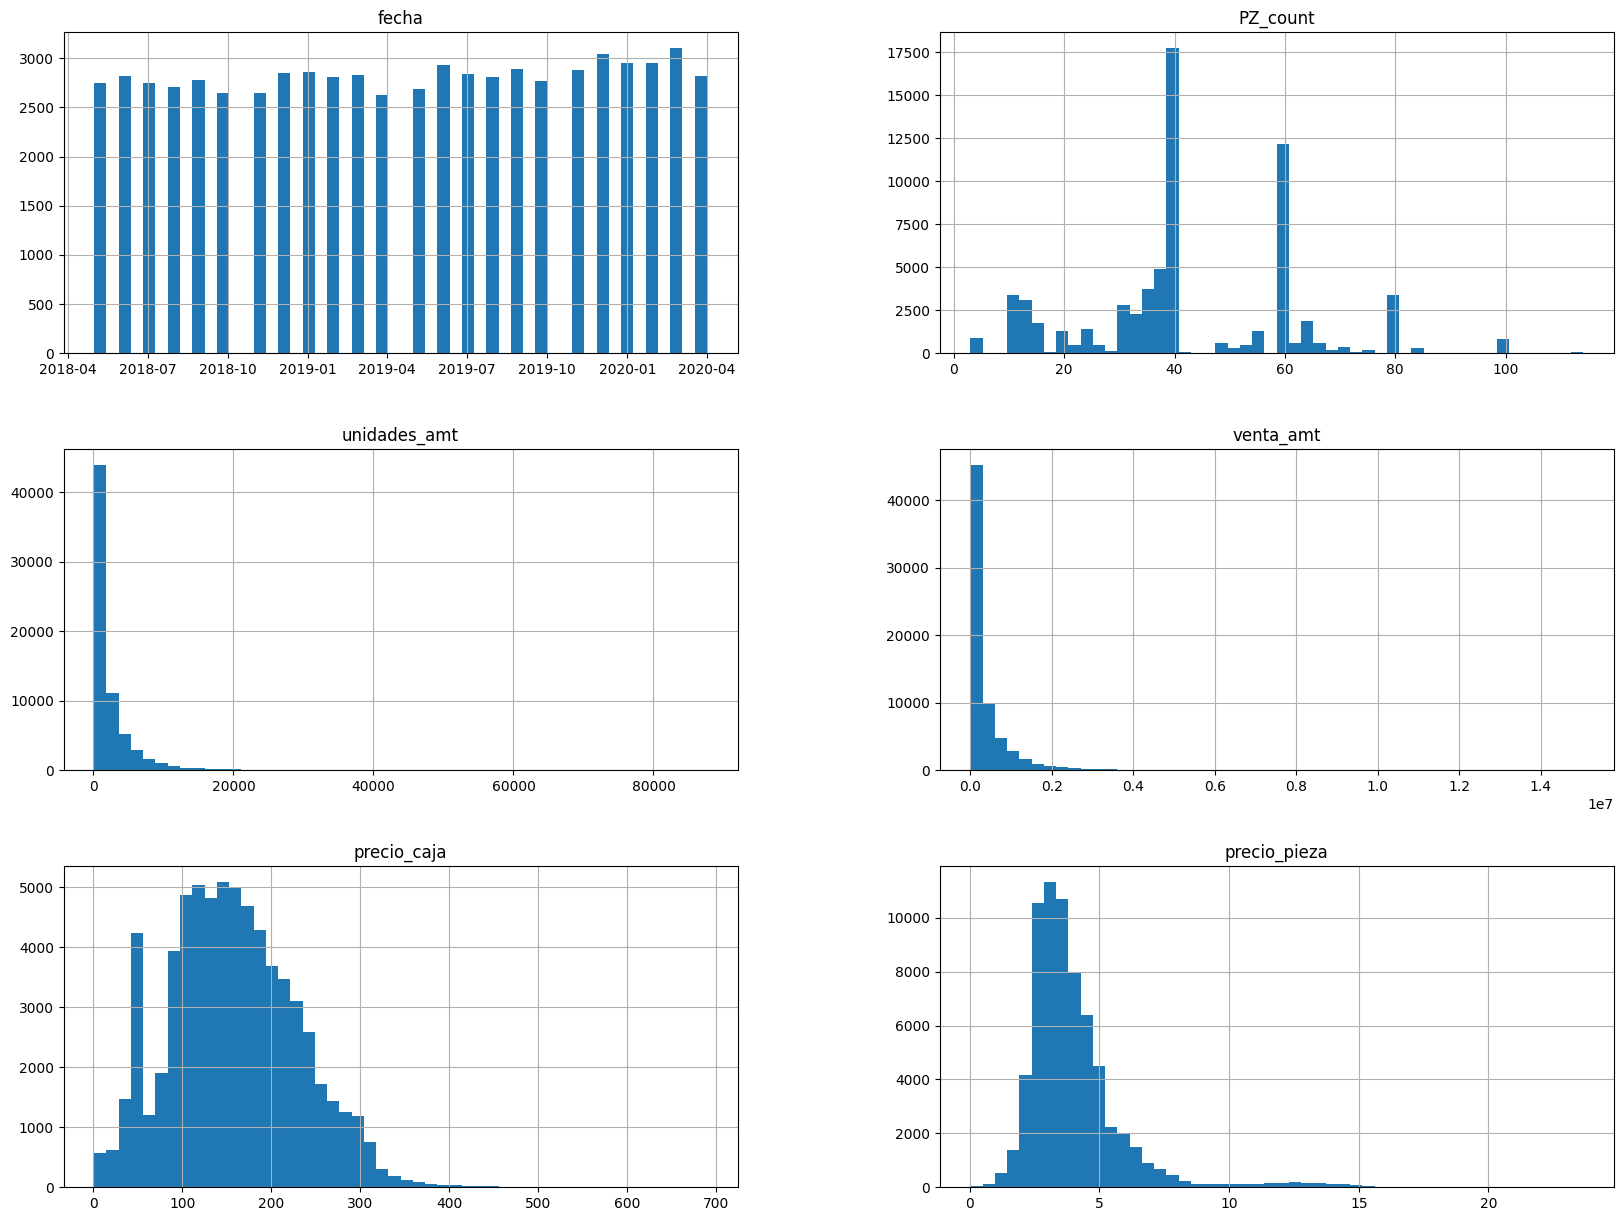

In [ ]:
# histogramas
df.hist(bins=50, figsize=(20,15))
plt.show()

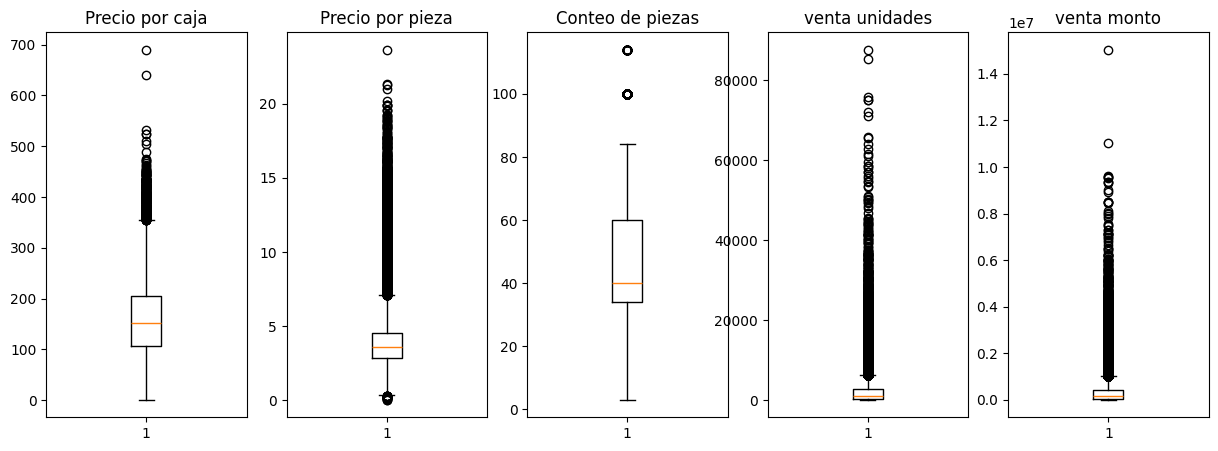

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(15, 5))

# First subplot
axs[0].boxplot(df['precio_caja'])
axs[0].set_title("Precio por caja")

# Second subplot
axs[1].boxplot(df['precio_pieza'])
axs[1].set_title("Precio por pieza")

# Third subplot
axs[2].boxplot(df['PZ_count'])
axs[2].set_title("Conteo de piezas")

# Fourt subplot
axs[3].boxplot(df['unidades_amt'])
axs[3].set_title("venta unidades")

# Fifth subplot
axs[4].boxplot(df['venta_amt'])
axs[4].set_title("venta monto")

plt.show()

Multivariate Outlier Detection

In [ ]:
from sklearn.ensemble import IsolationForest

# Isolate outliers using Isolation Forest
model = IsolationForest(random_state=42)

df['outlier_score'] = model.fit_predict(df[['precio_caja', 'precio_pieza']])

multivariate_outliers = df[df['outlier_score'] == -1]

multivariate_outliers.head(3)

,fecha,fabricante_desc,marca_desc,sub_marca_desc,etapa_desc,item_desc,banner_desc,region_desc,PZ_count,unidades_amt,venta_amt,precio_caja,precio_pieza,outlier_score
2,2018-05-01,KIMBERLY-CLARK,GOODNITES,GOODNITES,ETAPA 7,9PULL-UPS GOOD NITES MEDIANO UNISEX BSA.11IMP....,AUTO3,Centro,11,375,47375,126.333333,11.484848,-1
3,2018-05-01,KIMBERLY-CLARK,GOODNITES,GOODNITES,ETAPA 7,9PULL-UPS GOOD NITES MEDIANO UNISEX BSA.11IMP....,AUTO3,Norte,11,250,35250,141.000000,12.818182,-1
4,2018-05-01,KIMBERLY-CLARK,GOODNITES,GOODNITES,ETAPA 7,9PULL-UPS GOOD NITES MEDIANO UNISEX BSA.11IMP....,AUTO3,Occidente,11,500,57250,114.500000,10.409091,-1


Univariate Outliers

In [ ]:
#se encuentra el nivel superior e inferior de quartiles y su rango interquartil

q1_ppieza = np.percentile(df['precio_pieza'],25)
q3_pppieza = np.percentile(df['precio_pieza'],75)
intQ_range_superprice= q3_pppieza - q1_ppieza

#supuesto de Tukey
Lower_fence_ppieza = q1_ppieza - 1.5*intQ_range_superprice
Upper_fence_ppieza = q3_pppieza + 1.5*intQ_range_superprice

#representa los outliers - aquellos que esten fuera del supuesto de Tukey
Outlying_obs_pre = df[(df.precio_pieza<Lower_fence_ppieza) | (df.precio_pieza > Upper_fence_ppieza)]

#Data sin outliers
df = df[((df.precio_pieza>=Lower_fence_ppieza) & (df.precio_pieza<=Upper_fence_ppieza))]

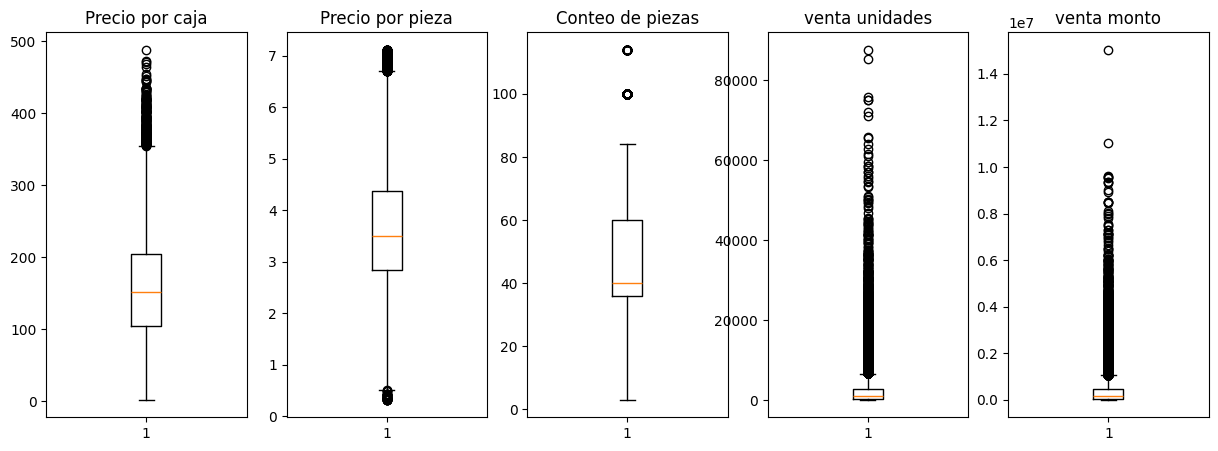

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(15, 5))

# First subplot
axs[0].boxplot(df['precio_caja'])
axs[0].set_title("Precio por caja")

# Second subplot
axs[1].boxplot(df['precio_pieza'])
axs[1].set_title("Precio por pieza")

# Third subplot
axs[2].boxplot(df['PZ_count'])
axs[2].set_title("Conteo de piezas")

# Fourt subplot
axs[3].boxplot(df['unidades_amt'])
axs[3].set_title("venta unidades")

# Fifth subplot
axs[4].boxplot(df['venta_amt'])
axs[4].set_title("venta monto")

plt.show()

Definición de periodos

Realizando un ajuste en el dataset, se tiene un total de 64k registros. Se observa que los periodos cuenta con similares cantidades de registros.

In [ ]:
df.shape

(64308, 14)

<Axes: >

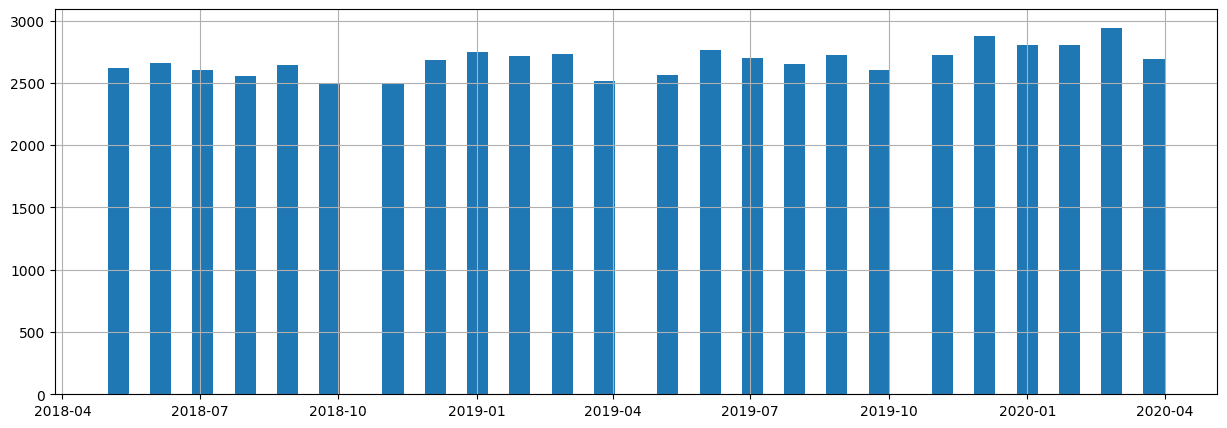

In [ ]:
df['fecha'].hist(bins=50, figsize=(15,5))

In [ ]:
df['fecha'].unique()

<DatetimeArray>
['2018-05-01 00:00:00', '2018-06-01 00:00:00', '2018-07-01 00:00:00',
 '2018-08-01 00:00:00', '2018-09-01 00:00:00', '2018-10-01 00:00:00',
 '2018-11-01 00:00:00', '2018-12-01 00:00:00', '2019-01-01 00:00:00',
 '2019-02-01 00:00:00', '2019-03-01 00:00:00', '2019-04-01 00:00:00',
 '2019-05-01 00:00:00', '2019-06-01 00:00:00', '2019-07-01 00:00:00',
 '2019-08-01 00:00:00', '2019-09-01 00:00:00', '2019-10-01 00:00:00',
 '2019-11-01 00:00:00', '2019-12-01 00:00:00', '2020-01-01 00:00:00',
 '2020-02-01 00:00:00', '2020-03-01 00:00:00', '2020-04-01 00:00:00']
Length: 24, dtype: datetime64[ns]

In [ ]:
#filter dates

q1 = df[(df['fecha'] > "2018-12-01 00:00:00") & (df['fecha'] < "2019-05-01 00:00:00")]
q2 = df[(df['fecha'] > "2019-12-01 00:00:00") & (df['fecha'] < "2020-05-01 00:00:00")]

df = pd.concat([q1, q2])

df.shape

(21945, 14)

Base de datos para su integración en Power BI, y realizar los análisis técnicos necesarios: evolutivos de venta, desempeño regional y análisis de pareto

In [ ]:
# dataset for BI
df.to_excel("panales_walmart.xlsx")

# ANALISIS DE REGIÓN CRÍTICA

## Analisis de Portafolios

### Eficiencia de Pareto por marca

La eficiencia de Pareto se analiza solo para el Q1-2020.

Por calculos de MS, se determina que la región Pacifico de WM presenta una participación de 33%, debajo del promedio general del Market Share es de 56% (un diferencial de 24pp). Para el caso de la competencia, el promedio del Market Share es de 44%, siendo para la región Pacifico con mayor participación de 67%.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21945 entries, 21931 to 67761
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            21945 non-null  datetime64[ns]
 1   fabricante_desc  21945 non-null  object        
 2   marca_desc       21945 non-null  object        
 3   sub_marca_desc   21945 non-null  object        
 4   etapa_desc       21945 non-null  object        
 5   item_desc        21945 non-null  object        
 6   banner_desc      21945 non-null  object        
 7   region_desc      21945 non-null  object        
 8   PZ_count         21945 non-null  int64         
 9   unidades_amt     21945 non-null  int64         
 10  venta_amt        21945 non-null  int64         
 11  precio_caja      21945 non-null  float64       
 12  precio_pieza     21945 non-null  float64       
 13  outlier_score    21945 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64

In [ ]:
# label of walmart
df['banner_desc'].unique()

df["grupo_desc"] = np.where(df['banner_desc'].isin(['AUTO4','AUTO3','AUTO1','AUTO2','AUTO5']), 'walmart','competencia')

In [ ]:
import numpy as np

pareto = pd.pivot_table(data=df[(df['fecha'] > "2019-12-01 00:00:00") & (df['region_desc']== "Pacifico") & (df['grupo_desc']=="walmart")],
                           index=["marca_desc"],
                           values=["unidades_amt"],
                           aggfunc=np.sum,
                           fill_value=0)

pareto = pareto[~(pareto == 0).all(axis=1)]

pareto = pareto.sort_values(by="unidades_amt", ascending=False)


#add column to display cumulative percentage
pareto['cumperc'] = pareto['unidades_amt'].cumsum()/pareto['unidades_amt'].sum()*100

#view DataFrame
pareto

/tmp/ipython-input-1226282587.py:3: FutureWarning: The provided callable <function sum at 0x7c402234f7e0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pareto = pd.pivot_table(data=df[(df['fecha'] > "2019-12-01 00:00:00") & (df['region_desc']== "Pacifico") & (df['grupo_desc']=="walmart")],


,unidades_amt,cumperc
marca_desc,,
CHICOLASTIC,399750,37.294461
HUGGIES,311375,66.344023
KLEEN BEBE,269875,91.521866
OTHERS MARCA UNIF.,49625,96.151603
BABY PANTS,21000,98.110787
BIOBABY,17500,99.743440
PAMPERS,2250,99.953353
BIO TRAINIES,500,100.000000


In [ ]:
# count products by group of brand
unique_products_by_marca = df.groupby('marca_desc')['item_desc'].nunique().reset_index()

# rename columns
unique_products_by_marca = unique_products_by_marca.rename(columns={'item_desc': 'unique_product_count'})

# Pareto + count of products by brand
pd.merge(pareto, unique_products_by_marca, on='marca_desc', how='left')

,marca_desc,unidades_amt,cumperc,unique_product_count
0,CHICOLASTIC,399750,37.294461,80
1,HUGGIES,311375,66.344023,89
2,KLEEN BEBE,269875,91.521866,80
3,OTHERS MARCA UNIF.,49625,96.151603,69
4,BABY PANTS,21000,98.110787,11
5,BIOBABY,17500,99.743440,11
6,PAMPERS,2250,99.953353,16
7,BIO TRAINIES,500,100.000000,2


/tmp/ipython-input-119762051.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pareto.index, rotation=90)


Text(0, 0.5, 'Eficiencia (%)')

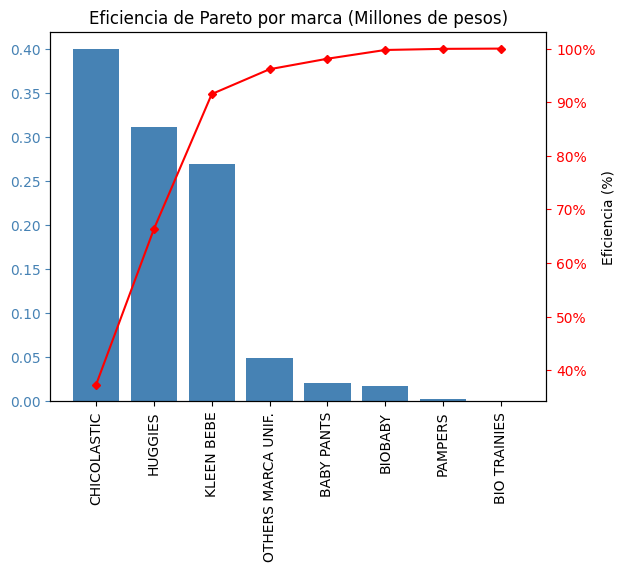

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

#define aesthetics for plot
color1 = 'steelblue'
color2 = 'red'
line_size = 4

#create basic bar plot
fig, ax = plt.subplots()
ax.bar(pareto.index, pareto['unidades_amt']/1000000, color=color1)

#add cumulative percentage line to plot
ax2 = ax.twinx()
ax2.plot(pareto.index, pareto['cumperc'], color=color2, marker="D", ms=line_size)
ax2.yaxis.set_major_formatter(PercentFormatter())

#specify axis colors
ax.tick_params(axis='y', colors=color1)
ax2.tick_params(axis='y', colors=color2)

# x-axis horizontal
ax.set_xticklabels(pareto.index, rotation=90)

# add title and subtitle in twice sides
plt.title('Eficiencia de Pareto por marca (Millones de pesos)')
ax2.set_ylabel('Eficiencia (%)')

### Eficiencia de Pareto por item

Dado el CAGR por región, la region Sureste es considerada como región critica al tener la mayor tasa de crecimiento negativo en 6%.

Por lo que se proce a realizar una análisis de su portafolio en la mayor desagragación posible. Se consideran todo los banners y la marca de Kleen Bebe

In [ ]:
# dataset region-marca

dff =df[(df['fecha'] > "2019-12-01 00:00:00") &
        (df['region_desc']== "Pacifico") &       # región de interes
        (df['grupo_desc']=="competencia")  &  # "walmart" & "competencia"
        (df['marca_desc'] == "HUGGIES")
        #(df['banner_desc'] == "RESTO")        # 'RESTO', 'AUTO4', 'AUTO3', 'AUTO1', 'AUTO2', 'AUTO5'
        ]
dff.shape

(168, 15)

In [ ]:
pareto = pd.pivot_table(data=dff,
                           index=["item_desc"],
                           values=["unidades_amt"],
                           aggfunc=np.sum,
                           fill_value=0)

pareto = pareto[~(pareto == 0).all(axis=1)]

pareto = pareto.sort_values(by="unidades_amt", ascending=False)


#add column to display cumulative percentage
pareto['cumperc'] = pareto['unidades_amt'].cumsum()/pareto['unidades_amt'].sum()*100

# view onlye above of 81 in cumperc
pareto = pareto[pareto['cumperc'] <= 80]

# label of pareto
pareto['pareto'] = np.where(pareto['cumperc'] <= 80, 'aprobado', 'reprobado')

#view DataFrame
pareto

/tmp/ipython-input-3322626635.py:1: FutureWarning: The provided callable <function sum at 0x7c402234f7e0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pareto = pd.pivot_table(data=dff,


,unidades_amt,cumperc,pareto
item_desc,,,
HUGGIES ALL AROUND PANAL ETAPA 6 UNISEX BOLSA 40PZAS 7501943488687,44000,8.335307,aprobado
HUGGIES ULTRACONFORT T2 UNISEX 40 PZS. NAL 7501943433090,38500,15.628700,aprobado
HUGGIES ALL AROUND PANAL ETAPA 5 UNISEX BOLSA 40PZAS 7501943488663,32500,21.785461,aprobado
HUGGIES ULTRACONFORT PANAL ETAPA 6 NINO BSA 60PZAS 7501943417120,32250,27.894861,aprobado
HUGGIES ULTRACONFORT PANAL ETAPA 5 NINA BSA 60PZAS 7501943416741,29125,33.412266,aprobado
HUGGIES ULTRACONFORT PANAL ETAPA 6 NINA BSA 60PZAS 7501943417144,29000,38.905991,aprobado
HUGGIES ULTRACONFORT PANAL ETAPA 5 NINO BSA 60PZAS 7501943416727,28375,44.281317,aprobado
HUGGIES ULTRACONFORT ETAPA 6 NINO BOLSA 40PZS 7506425604364,19875,48.046413,aprobado
HUGGIES ULTRACONFORT ETAPA 6 NINA BOL 40PZS 7506425604388,19375,51.716789,aprobado


In [ ]:
pareto.to_excel("pareto.xlsx")

In [ ]:
# select two columns in pareto
pareto = pareto.reset_index()

pareto = pareto[['item_desc', 'pareto']]

# data set of paretto
dff_pareto= pd.merge(dff, pareto, on='item_desc', how='left')

dff_pareto = dff_pareto[dff_pareto["pareto"]=="aprobado"]

dff_pareto.to_excel("pareto_dff.xlsx")

dff_pareto.head(5)

,fecha,fabricante_desc,marca_desc,sub_marca_desc,etapa_desc,item_desc,banner_desc,region_desc,PZ_count,unidades_amt,venta_amt,precio_caja,precio_pieza,outlier_score,grupo_desc,pareto
1,2020-01-01,KIMBERLY-CLARK,HUGGIES,ALL AROUND,ETAPA 4,HUGGIES ALL AROUND PANAL ETAPA 4 UNISEX BOLSA ...,RESTO,Pacifico,40,2000,348000,174.000000,4.350000,1,competencia,aprobado
2,2020-01-01,KIMBERLY-CLARK,HUGGIES,ALL AROUND,ETAPA 5,HUGGIES ALL AROUND PANAL ETAPA 5 UNISEX BOLSA ...,RESTO,Pacifico,40,5625,975500,173.422222,4.335556,1,competencia,aprobado
3,2020-01-01,KIMBERLY-CLARK,HUGGIES,ALL AROUND,ETAPA 6,HUGGIES ALL AROUND PANAL ETAPA 6 UNISEX BOLSA ...,RESTO,Pacifico,40,8125,1437125,176.876923,4.421923,1,competencia,aprobado
15,2020-01-01,KIMBERLY-CLARK,HUGGIES,SUPREME,ETAPA 1,HUGGIES SUPREME PANAL ETAPA 1 38PZA 7501943416864,RESTO,Pacifico,38,5000,720125,144.025000,3.790132,1,competencia,aprobado
21,2020-01-01,KIMBERLY-CLARK,HUGGIES,SUPREME,RECIEN NACIDO,HUGGIES SUPREME PURE&NATURAL PANALES ETAPA RN ...,RESTO,Pacifico,38,4375,568125,129.857143,3.417293,1,competencia,aprobado


## Elasticidad Precio de la Demanda (unitaria)

### Construccion del dataset

Elasticidad Precio de la Demanda por Regresion Lineal:


*   Coefficient (Slope) * Price mean / Quantity mean



In [ ]:
dff.columns

Index(['fecha', 'fabricante_desc', 'marca_desc', 'sub_marca_desc',
       'etapa_desc', 'item_desc', 'banner_desc', 'region_desc', 'PZ_count',
       'unidades_amt', 'venta_amt', 'precio_caja', 'precio_pieza',
       'outlier_score', 'grupo_desc'],
      dtype='object')

Establecemos la variable independiente **precio $** como **"x_value"**

In [ ]:
dff = dff_pareto.copy()

# Tabla pivote transpuesta para la variable independiente
x_pivot = dff.pivot_table(index=["fecha"],
                             columns='item_desc',
                             values='venta_amt',
                             aggfunc='sum',
                             fill_value = 0)

# Convertir el Dataframe en un arreglo de Numpy Record
x_values = pd.DataFrame(x_pivot.to_records())

# eliminamos valores nulos a nivel columna
#x_values= x_values.dropna(axis=1)

x_values.head()

,fecha,HUGGIES ALL AROUND PANAL ETAPA 4 UNISEX BOLSA 40PZAS 7501943488649,HUGGIES ALL AROUND PANAL ETAPA 5 UNISEX BOLSA 40PZAS 7501943488663,HUGGIES ALL AROUND PANAL ETAPA 6 UNISEX BOLSA 40PZAS 7501943488687,HUGGIES SUPREME PANAL ETAPA 1 38PZA 7501943416864,HUGGIES SUPREME PURE&NATURAL PANALES ETAPA RN UNISX BSA38PZA 7501943416178,HUGGIES ULTRACONFORT ETAPA 4 NINA BOL 40PZS 7506425604302,HUGGIES ULTRACONFORT ETAPA 5 NINA BOL 40PZS 7506425604340,HUGGIES ULTRACONFORT ETAPA 5 NINO BOLSA 40PZS 7506425604326,HUGGIES ULTRACONFORT ETAPA 6 NINA BOL 40PZS 7506425604388,HUGGIES ULTRACONFORT ETAPA 6 NINO BOLSA 40PZS 7506425604364,HUGGIES ULTRACONFORT PANAL ETAPA 4 NINA BSA 60PZAS 7501943416703,HUGGIES ULTRACONFORT PANAL ETAPA 4 NINO BSA 60PZAS 7501943416680,HUGGIES ULTRACONFORT PANAL ETAPA 5 NINA BSA 60PZAS 7501943416741,HUGGIES ULTRACONFORT PANAL ETAPA 5 NINO BSA 60PZAS 7501943416727,HUGGIES ULTRACONFORT PANAL ETAPA 6 NINA BSA 60PZAS 7501943417144,HUGGIES ULTRACONFORT PANAL ETAPA 6 NINO BSA 60PZAS 7501943417120,HUGGIES ULTRACONFORT T2 UNISEX 40 PZS. NAL 7501943433090
0,2020-01-01,348000,975500,1437125,720125,568125,720500,864875,791250,826000,880000,1198125,1096625,1803875,1761375,1698250,1934500,1427375
1,2020-02-01,498625,1084250,1576500,615750,540125,724875,854000,832000,887750,939625,1244250,1070125,1876000,1911625,1920000,2033375,1456375
2,2020-03-01,1061375,2069625,2745875,683125,601500,1052000,1167500,1182500,1383000,1395500,1671000,1432375,2820000,2684750,2908625,3349750,1821500
3,2020-04-01,623750,1092000,1703125,455000,417500,671000,654625,746750,893000,893750,1001125,806000,1862000,1694750,1907375,2084750,1090500


In [ ]:
x_values.to_excel("x_values.xlsx")

Establecemos la variable dependiente **paquetes vendidos** como **"y_value"**

In [ ]:
y_pivot = dff.pivot_table( index = 'fecha',
                              columns='item_desc',
                              values='unidades_amt',
                              aggfunc='sum',
                              fill_value = 0)

# Convertir el Dataframe en un arreglo de Numpy Record
y_values = pd.DataFrame(y_pivot.to_records())

# eliminamos valores nulos a nivel columna
#y_values= y_values.dropna(axis=1)

y_values.head()

,fecha,HUGGIES ALL AROUND PANAL ETAPA 4 UNISEX BOLSA 40PZAS 7501943488649,HUGGIES ALL AROUND PANAL ETAPA 5 UNISEX BOLSA 40PZAS 7501943488663,HUGGIES ALL AROUND PANAL ETAPA 6 UNISEX BOLSA 40PZAS 7501943488687,HUGGIES SUPREME PANAL ETAPA 1 38PZA 7501943416864,HUGGIES SUPREME PURE&NATURAL PANALES ETAPA RN UNISX BSA38PZA 7501943416178,HUGGIES ULTRACONFORT ETAPA 4 NINA BOL 40PZS 7506425604302,HUGGIES ULTRACONFORT ETAPA 5 NINA BOL 40PZS 7506425604340,HUGGIES ULTRACONFORT ETAPA 5 NINO BOLSA 40PZS 7506425604326,HUGGIES ULTRACONFORT ETAPA 6 NINA BOL 40PZS 7506425604388,HUGGIES ULTRACONFORT ETAPA 6 NINO BOLSA 40PZS 7506425604364,HUGGIES ULTRACONFORT PANAL ETAPA 4 NINA BSA 60PZAS 7501943416703,HUGGIES ULTRACONFORT PANAL ETAPA 4 NINO BSA 60PZAS 7501943416680,HUGGIES ULTRACONFORT PANAL ETAPA 5 NINA BSA 60PZAS 7501943416741,HUGGIES ULTRACONFORT PANAL ETAPA 5 NINO BSA 60PZAS 7501943416727,HUGGIES ULTRACONFORT PANAL ETAPA 6 NINA BSA 60PZAS 7501943417144,HUGGIES ULTRACONFORT PANAL ETAPA 6 NINO BSA 60PZAS 7501943417120,HUGGIES ULTRACONFORT T2 UNISEX 40 PZS. NAL 7501943433090
0,2020-01-01,2000,5625,8125,5000,4375,3625,4250,3875,3875,4125,4375,4000,6375,6250,5875,6750,9625
1,2020-02-01,3000,6375,8875,3875,4125,3875,4500,4375,4500,4750,4625,4000,6875,7000,7000,7375,9750
2,2020-03-01,7750,14500,18250,4125,4375,5500,6000,6000,7000,7125,5875,5125,10000,9625,10125,11750,12000
3,2020-04-01,3625,6000,8750,2750,3000,3125,3125,3500,4000,3875,3375,2750,5875,5500,6000,6375,7125


### Modelo de Regresion General

In [ ]:
# metricas
points = []
results_values = {
    "item_desc": [],
    "price_elasticity": [],
    "price_mean": [],
    "quantity_mean": [],
    "intercept": [],
    "t_score":[],
    "slope": [],
    "coefficient_pvalue" : [],
    "r2": [],
}

# Append x_values with y_values per same product name
for column in x_values.columns[1:]:
    column_points = []
    for i in range(len(x_values[column])):
        if not np.isnan(x_values[column][i]) and not np.isnan(y_values[column][i]):
            column_points.append((x_values[column][i], y_values[column][i]))
    mercado = pd.DataFrame(list(column_points), columns= ['x_value', 'y_value'])

# Linear Regression Model
    import statsmodels.api as sm
    x_value = mercado['x_value']
    y_value = mercado['y_value']
    X = sm.add_constant(x_value)
    model = sm.OLS(y_value, X)
    result = model.fit()


# (Null Hypothesis test) Coefficient with a p value less than 0.05
    if result.f_pvalue < 0.05:

        rsquared = result.rsquared
        coefficient_pvalue = result.f_pvalue
        intercept, slope = result.params
        mean_price = np.mean(x_value)
        mean_quantity = np.mean(y_value)
        tintercept, t_score = result.tvalues

#Price elasticity Formula
        price_elasticity = (slope)*(mean_price/mean_quantity)

#Append results into dictionary for dataframe
        results_values["item_desc"].append(column)
        results_values["price_elasticity"].append(price_elasticity)
        results_values["price_mean"].append(mean_price)
        results_values["quantity_mean"].append(mean_quantity)
        results_values["intercept"].append(intercept)
        results_values['t_score'].append(t_score)
        results_values["slope"].append(slope)
        results_values["coefficient_pvalue"].append(coefficient_pvalue)
        results_values["r2"].append(rsquared)

Visualizaremos los resultados de la regresión lineal a nivel mercado-sku-region.

In [ ]:
# construir el dataset con el diccionario del resultado
final_df = pd.DataFrame.from_dict(results_values)

# arreglo del dataset
df_elasticity =final_df[['item_desc','price_elasticity','t_score','coefficient_pvalue','slope','price_mean','quantity_mean','intercept', "r2"]]

# impresion y exportación
df_elasticity.to_excel("elasticidad_precio_demanda.xlsx")

df_elasticity

,item_desc,price_elasticity,t_score,coefficient_pvalue,slope,price_mean,quantity_mean,intercept,r2
0,HUGGIES ALL AROUND PANAL ETAPA 4 UNISEX BOLSA ...,1.264922,12.717861,0.006126,0.008181,632937.50,4093.75,-1084.524077,0.987786
1,HUGGIES ALL AROUND PANAL ETAPA 5 UNISEX BOLSA ...,1.333951,23.889503,0.001748,0.008303,1305343.75,8125.00,-2713.348489,0.996508
2,HUGGIES ALL AROUND PANAL ETAPA 6 UNISEX BOLSA ...,1.364167,10.372476,0.009167,0.008043,1865656.25,11000.00,-4005.835720,0.981750
3,HUGGIES SUPREME PANAL ETAPA 1 38PZA 7501943416864,1.197492,5.144557,0.035769,0.007623,618500.00,3937.50,-777.626235,0.929742
4,HUGGIES SUPREME PURE&NATURAL PANALES ETAPA RN ...,1.076236,7.261187,0.018443,0.008032,531812.50,3968.75,-302.560715,0.963454
5,HUGGIES ULTRACONFORT ETAPA 4 NINA BOL 40PZS 75...,1.135963,7.927754,0.015541,0.005781,792093.75,4031.25,-548.099554,0.969159
6,HUGGIES ULTRACONFORT ETAPA 5 NINA BOL 40PZS 75...,1.100211,11.911397,0.006974,0.005554,885250.00,4468.75,-447.818403,0.986100
7,HUGGIES ULTRACONFORT ETAPA 5 NINO BOLSA 40PZS ...,1.092410,8.879649,0.012446,0.005458,888125.00,4437.50,-410.070841,0.975262
8,HUGGIES ULTRACONFORT ETAPA 6 NINA BOL 40PZS 75...,1.150853,9.461316,0.010987,0.005589,997437.50,4843.75,-730.693159,0.978146
9,HUGGIES ULTRACONFORT ETAPA 6 NINO BOLSA 40PZS ...,1.225394,8.368552,0.013980,0.005927,1027218.75,4968.75,-1119.926856,0.972235


## Analisis de Precios

Estadistica descriptiva

In [ ]:
precios = dff_pareto.groupby(["etapa_desc","PZ_count","marca_desc"])[["precio_caja"]].describe().round(2)

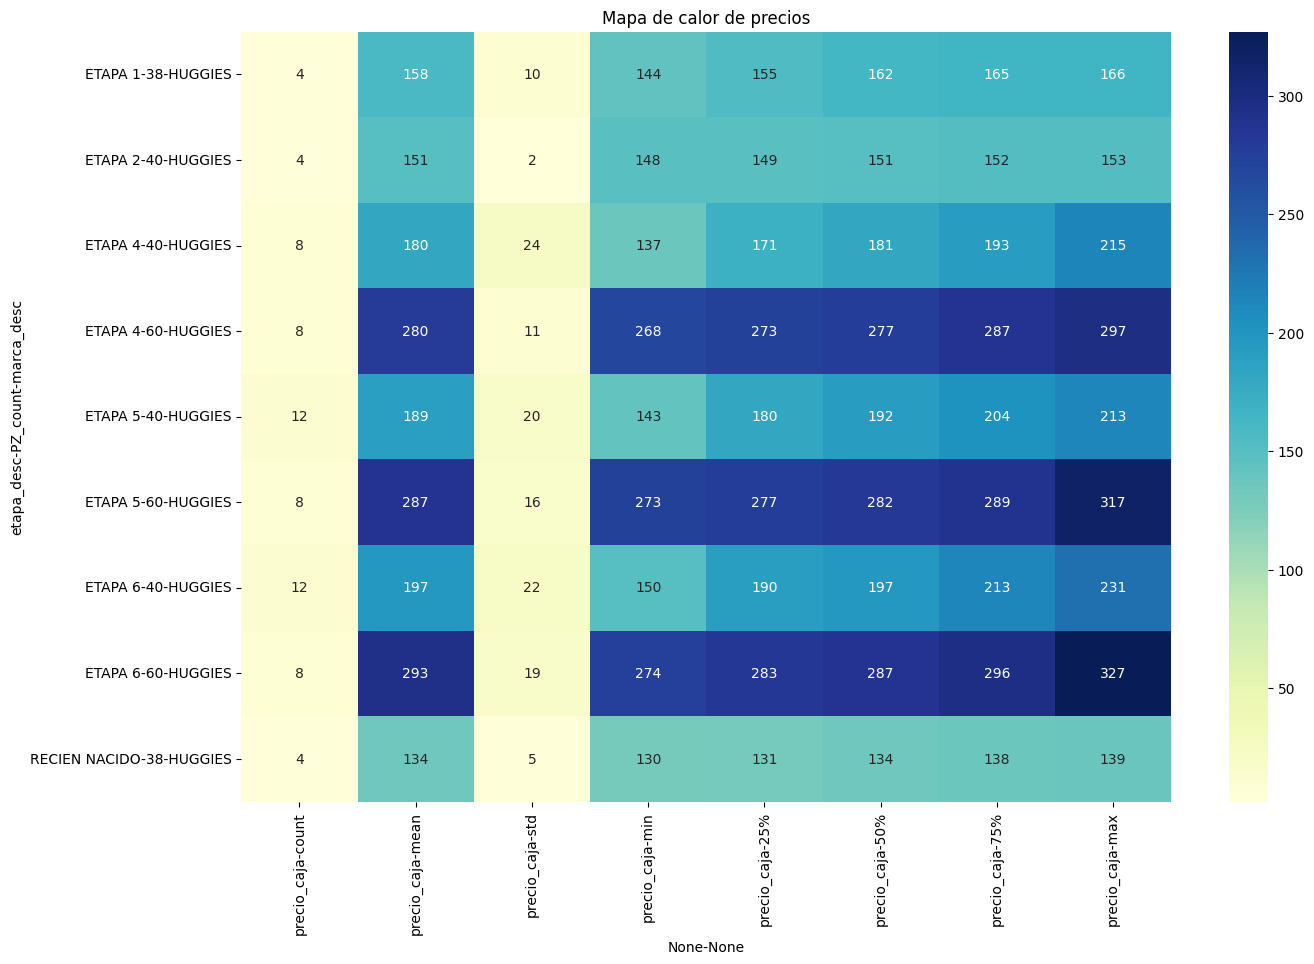

In [ ]:
# Flatten the MultiIndex DataFrame for heatmap
precios_flat = precios.reset_index()

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(precios_flat.set_index(['etapa_desc', 'PZ_count', 'marca_desc']), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Mapa de calor de precios')
plt.show()

# Cuota de mercados

In [ ]:
# Create a pivot table with 'grupo_desc' and 'item_desc' as index and 'fecha' as columns
market_share_pivot = dff.pivot_table(index=["grupo_desc", "fecha"],
                                     columns="item_desc",
                                     values="venta_amt",
                                     aggfunc='sum',
                                     fill_value=0)

# drop columns that contain any zero
cols_with_zeros = market_share_pivot.columns[(market_share_pivot == 0).any()]
market_share_pivot = market_share_pivot.drop(columns = cols_with_zeros)

market_share_pivot.to_excel("market_share.xlsx")